<a href="https://colab.research.google.com/github/JMK9904/ba_framing_yt-kommentare/blob/main/BA_Topic_Modeling_Bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip uninstall gensim -y
#!pip install gensim==4.3.3
!pip install bertopic sentence-transformers umap-learn hdbscan gensim nltk dask[complete] HanTa scikit-optimize
!pip install octis==1.14.0 --no-deps


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 13.2 MB/s eta 0:00:00


In [ ]:
!pip uninstall torchao


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchao-0.10.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchao/*
Proceed (Y/n)? y
  Successfully uninstalled torchao-0.10.0


In [ ]:
from huggingface_hub import login

login(HF_TOKEN)


import torch
from transformers import AutoModel

model = AutoModel.from_pretrained(
    "jinaai/jina-embeddings-v5-text-small",
    trust_remote_code=True,
    dtype=torch.bfloat16,
)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

config.json:   0%|          | 0.00/991 [00:00<?, ?B/s]

configuration_jina_embeddings_v5.py:   0%|          | 0.00/120 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-small:
- configuration_jina_embeddings_v5.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_jina_embeddings_v5.py:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-small:
- modeling_jina_embeddings_v5.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

JinaEmbeddingsV5Model(
  (base_model): MixedModel(
    (model): Qwen3Model(
      (embed_tokens): Embedding(151936, 1024)
      (layers): ModuleList(
        (0-27): 28 x Qwen3DecoderLayer(
          (self_attn): Qwen3Attention(
            (q_proj): lora.Linear(
              (base_layer): Linear(in_features=1024, out_features=2048, bias=False)
              (lora_dropout): ModuleDict(
                (retrieval): Dropout(p=0.1, inplace=False)
                (text-matching): Dropout(p=0.1, inplace=False)
                (clustering): Dropout(p=0.1, inplace=False)
                (classification): Dropout(p=0.05, inplace=False)
              )
              (lora_A): ModuleDict(
                (retrieval): Linear(in_features=1024, out_features=32, bias=False)
                (text-matching): Linear(in_features=1024, out_features=32, bias=False)
                (clustering): Linear(in_features=1024, out_features=32, bias=False)
                (classification): Linear(in_features=1024

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
model = model.cuda()

In [ ]:
#import optuna
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
import umap
import hdbscan
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from pathlib import Path
import pandas as pd
import numpy as np
import re
from HanTa.HanoverTagger import HanoverTagger as ht
import dask.dataframe as dd
from octis.optimization.optimizer import Optimizer
from skopt.space.space import Real

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filtered_data = dd.read_parquet("/content/drive/MyDrive/Bachelor Thesis/public_media_data/filtered_data.parquet")

In [ ]:
full_data = dd.read_parquet("/content/drive/MyDrive/Bachelor Thesis/public_media_data/full_data.parquet")

#Deskriptive Maße

In [ ]:
filtered_data.columns

Index(['video_id', 'video_title', 'video_published', 'comment_id', 'parent_id',
       'likes', 'is_reply', 'text', 'comment_published', 'author',
       'source_file', 'channel', 'year', 'quarter'],
      dtype='object')

In [ ]:
################################
###########grundlegendes########
################################

n_comments = len(filtered_data)
n_videos = filtered_data["video_id"].compute().nunique()


print(f"Kommentare gesamt: {n_comments}")
print(f"Videos gesamt: {n_videos}")



Kommentare gesamt: 45733
Videos gesamt: 2886


In [ ]:
df = filtered_data.compute()
videos = df[["video_id", "video_title"]].drop_duplicates()
comments_per_video = df["video_id"].value_counts()
print(comments_per_video.describe())
videos["video_title"].sample(10)

count       2886.0
mean       15.8465
std      45.446596
min            1.0
25%            2.0
50%            6.0
75%           17.0
max         2057.0
Name: count, dtype: double[pyarrow]


,video_title
2814935,Mensch Merz! Der Herausforderer | ZDFzeit
3650816,Reportage: Was die Deutschen über die Neuwahle...
2228194,Russland intensiviert Angriffe: Wie lang kann ...
1181576,Zurück in Israel: Wie groß ist die Hoffnung au...
3734720,Ukraine-Krieg: Wird er die Wahl entscheiden? |...
1777636,Hat Crystal Meth den Irak im Griff? | auslands...
1743453,"Wirtschaftskrise: Scheitern Scholz, Habeck und..."
301358,"tagesschau 20:00 Uhr, 17.12.2025"
206363,"tagesschau 20:00 Uhr, 10.02.2025"
177971,"tagesschau 20:00 Uhr, 15.01.2025"


In [ ]:
video_stats = (
    df.groupby("video_id")
      .agg({
          "text": "count",           # Anzahl Kommentare
          "video_title": "first",    # Titel (einfach ersten nehmen)
          "video_date": "first"      # Datum
      })
      .rename(columns={"text": "n_comments"})
)


top_videos = video_stats.sort_values("n_comments", ascending=False).head(5)
print(top_videos['video_date'])
for i, row in top_videos.iterrows():
    print(f"{row['video_title']} ({row['n_comments']} Kommentare)")

video_id
onxwX3bx-UA   2025-04-09 13:30:02+00:00
rpINCu5VmnY   2024-05-31 07:00:33+00:00
leil2dJ0XUo   2023-06-29 18:32:48+00:00
gmscKMho07c   2023-11-16 09:18:10+00:00
VwRgOlXLOpQ   2023-10-28 09:51:42+00:00
Name: video_date, dtype: datetime64[ns, UTC]
Asylpolitik in Deutschland: Droht ein Kontrollverlust? I KLAR (2057 Kommentare)
Muslime in Deutschland: Zunehmend isoliert? | Markus Lanz vom 30. Mai 2024 (334 Kommentare)
tagesschau 20:00 Uhr, 29.06.2023 (312 Kommentare)
Nahost-Krieg: "Völkerrecht wird verletzt, und wir gucken zu" |  Markus Lanz vom 15. November 2023 (249 Kommentare)
Wie Islamisten den Nahost-Konflikt ausnutzen - und Hass in Deutschland schüren (223 Kommentare)


In [ ]:
from pandas.core.frame import DataFrame
df["video_date"] = pd.to_datetime(df["video_published"])
df["video_year"] = df["video_date"].dt.year
df["video_month"] = df['video_date'].dt.month


df["video_time"] = pd.to_datetime(
    df["video_year"].astype(str) + "-" + df["video_month"].astype(str)
)

videos_per_year = df.groupby("video_year")["video_id"].nunique()


videos_per_month = (
    df.groupby("video_time")["video_id"]
    .nunique()
    .sort_index()
)

In [ ]:
videos_per_month_df = videos_per_month.reset_index(name="n_videos")
videos_per_month_df

,video_time,n_videos
0,2023-05-01,67
1,2023-06-01,55
2,2023-07-01,66
3,2023-08-01,65
4,2023-09-01,67
5,2023-10-01,123
6,2023-11-01,102
7,2023-12-01,85
8,2024-01-01,104
9,2024-02-01,129


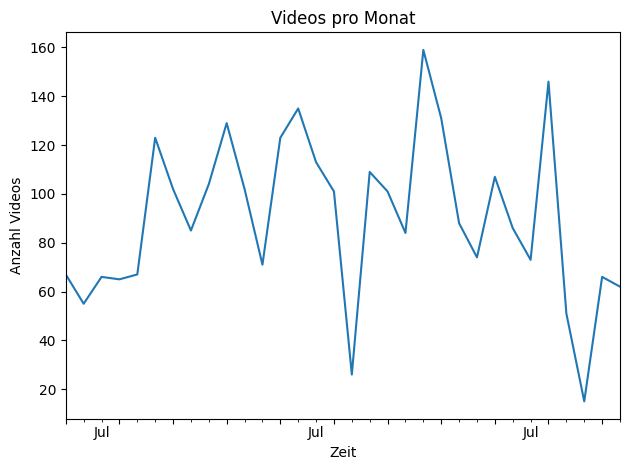

In [ ]:
plt.figure()

videos_per_month.plot()

plt.xticks(
    videos_per_month.index[::3],  # nur jedes 3. Label
    rotation=45
)

plt.xlabel("Zeit")
plt.ylabel("Anzahl Videos")
plt.title("Videos pro Monat")

plt.tight_layout()
plt.show()

In [ ]:
filtered_data["char_count"] = filtered_data["text"].compute().str.len()
filtered_data["word_count"] = filtered_data["text"].compute().str.split().str.len()

filtered_data[["char_count", "word_count"]].compute().describe()

,char_count,word_count
count,45733.0,45733.000000
mean,409.166051,60.063499
std,637.235852,91.425070
min,5.0,1.000000
25%,120.0,18.000000
50%,230.0,34.000000
75%,448.0,66.000000
max,9840.0,1497.000000


In [ ]:
filtered_data_df = filtered_data.compute()
desc = filtered_data_df.groupby(["year", "quarter"])[["char_count", "word_count"]].describe()
desc = desc.sort_values(("word_count", "count"), ascending=False)
print(desc.tail(5))


             char_count                                                    \
                  count        mean         std  min    25%    50%    75%   
year quarter                                                                
2023 Q3          3057.0  443.581289  757.032857  7.0  129.0  236.0  453.0   
2024 Q4          2874.0  401.806541  572.035443  7.0  115.0  228.5  450.0   
2023 Q2          2535.0  373.404339  520.431877  6.0  117.0  218.0  429.5   
2025 Q3          2367.0  403.286439  652.026781  6.0  115.5  217.0  435.0   
     Q4          1618.0  380.725587   673.84172  7.0  106.0  202.0  401.0   

                     word_count                                                \
                 max      count       mean         std  min   25%   50%   75%   
year quarter                                                                    
2023 Q3       9086.0     3057.0  64.595682  103.847833  1.0  19.0  36.0  66.0   
2024 Q4       7112.0     2874.0  58.911621   81.394386  1.0

In [ ]:
counts_2 = filtered_data["source_file"].compute().value_counts(dropna=False)
percentages_2 = filtered_data["source_file"].compute().value_counts(normalize=True, dropna=False) * 100

source_stats_2 = pd.DataFrame({
    "count": counts_2,
    "percent": percentages_2.round(2)
})

print(source_stats_2)


video_count = filtered_data['video_id'].compute().value_counts()
video_count_perc = filtered_data['video_id'].compute().value_counts(normalize=True, dropna=False) * 100

source_stats_3 = pd.DataFrame({
    "count": video_count,
    "percent": video_count_perc.round(2)
})

#print("Anzahl Kommentare pro Video:")
#print(source_stats_3)

quarter_count = filtered_data_df[['quarter', 'year']].value_counts()
quarter_count_perc = filtered_data_df[['quarter', 'year']].value_counts(normalize=True, dropna=False) * 100

source_stats_4 = pd.DataFrame({
    "count": quarter_count,
    "percent": quarter_count_perc.round(2)
})

print("Anzahl Kommentare pro Quartal:")
print(source_stats_4.tail(5))


'''
Grafik erstellen mit Häufig über Zeit pro Kanal.
Gleiches kann für durchschnittliche Zeichanzahl gemacht werden.


                                count  percent
source_file                                   
yt_comments_zdfheute_2023_Q4     4196     9.17
yt_comments_tagesschau_2025_Q1   3743     8.18
yt_comments_zdfheute_2025_Q1     3170     6.93
yt_comments_zdfheute_2024_Q2     3125     6.83
yt_comments_tagesschau_2023_Q4   3121     6.82
yt_comments_tagesschau_2025_Q2   3094     6.77
yt_comments_zdfheute_2024_Q1     2699      5.9
yt_comments_tagesschau_2024_Q1   2694     5.89
yt_comments_tagesschau_2024_Q2   2628     5.75
yt_comments_zdfheute_2024_Q3     1988     4.35
yt_comments_zdfheute_2024_Q4     1960     4.29
yt_comments_tagesschau_2023_Q2   1832     4.01
yt_comments_zdfheute_2023_Q3     1764     3.86
yt_comments_tagesschau_2024_Q3   1582     3.46
yt_comments_zdfheute_2025_Q3     1386     3.03
yt_comments_tagesschau_2023_Q3   1293     2.83
yt_comments_zdfheute_2025_Q2     1242     2.72
yt_comments_tagesschau_2025_Q4   1009     2.21
yt_comments_tagesschau_2025_Q3    981     2.15
yt_comments_t

mögliche Bots (Dublikate)

In [ ]:
########################################################
#############Zählen von identischen Kommentare##########
########################################################

# Sicherheits-Preprocessing
filtered_data["text_clean"] = (
    filtered_data["text"].compute()
    .astype(str)
    .str.strip()
)

# Häufigkeit identischer Kommentare
duplicate_counts = (
    filtered_data["text_clean"].compute()
    .value_counts()
    .reset_index()
)

duplicate_counts.columns = ["text", "count"]

# nur echt Dublikate
print('Nur echte Dublikate')

duplicates_only = duplicate_counts[duplicate_counts["count"] > 1]

print(f"Anzahl unterschiedlicher Duplikate: {len(duplicates_only)}")
print(f"Kommentare mit mind. 1 Duplikat: {duplicates_only['count'].sum()}")


# Anteil im Gesamtdatensatz
print('Anteile im Gesamtdatensatz')

total_comments = len(filtered_data)
duplicate_comment_instances = duplicates_only["count"].sum()

print(f"Gesamtkommentare: {total_comments}")
print(f"Kommentare mit Duplikaten: {duplicate_comment_instances}")
print(f"Anteil: {duplicate_comment_instances / total_comments:.2%}")


# top 20

duplicates_only.sort_values(
    by="count",
    ascending=False
).head(20)


# Dublikate pro Video
print('Dublikate pro Video:')

dup_per_video = (
    filtered_data.compute()
    .groupby(["video_id", "text_clean"])
    .size()
    .reset_index(name="count")
)

dup_per_video = dup_per_video[dup_per_video["count"] > 1]
print(dup_per_video["count"].sum())
print(f'Unterschiedliche Duplikate pro Video: {len(dup_per_video)}')
#print(dup_per_video.describe())


#user_activity = filtered_data_df.groupby("author").size()
#print('Nutzeraktivität:')
#print(user_activity.describe())
#print(user_activity.sort_values(ascending=False).head(100))
'''

Viel Kommentierer identifizieren.


'''


Nur echte Dublikate
Anzahl unterschiedlicher Duplikate: 683
Kommentare mit mind. 1 Duplikat: 1646
Anteile im Gesamtdatensatz
Gesamtkommentare: 45733
Kommentare mit Duplikaten: 1646
Anteil: 3.60%
Dublikate pro Video:
927
Unterschiedliche Duplikate pro Video: 415


'\n\nViel Kommentierer identifizieren.\n\n\n'

In [ ]:
print('Gesamt:')
print(duplicates_only.describe())

print('Pro Video:')

print(dup_per_video.describe())

'''

Beispiele der Häufigtsen Duplikate zeigen?

'''

Gesamt:
          count
count     683.0
mean   2.409956
std    1.203131
min         2.0
25%         2.0
50%         2.0
75%         2.0
max        15.0
Pro Video:
            count
count  415.000000
mean     2.233735
std      0.868571
min      2.000000
25%      2.000000
50%      2.000000
75%      2.000000
max     10.000000


# TM Prep

In [ ]:
comments_soldisk = filtered_data

In [ ]:
comments_soldisk["text"].isna().sum()
comments_soldisk = comments_soldisk.dropna(subset=["text"])

In [ ]:
df_test = comments_soldisk.sample(frac=0.25, random_state=42)
df_test = df_test.reset_index(drop=True)

In [ ]:
'''def process(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+', '<URL>', str(text))
    text = re.sub(r'@\w+', '<USER>', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text.lower().strip())

    words = [w for w in nltk.word_tokenize(text) if len(w) > 1]

    # DEBUG 1: Vor HanTa
    #print("\n--- VOR HANTA ---")
    #print(words[:30])

    tagged = tagger.tag_sent(words)

    # DEBUG 2: HanTa Ausgabe komplett
    #print("\n--- HANTA OUTPUT ---")
    #print(tagged[:30])

    lemmata = []

    for word, lemma, tag in tagged:
        if lemma not in stop_words and len(word) > 2:
            lemmata.append(lemma)

    # DEBUG 3: Endgültiger Output
    #print("\n--- NACH HANTA ---")
    #print(lemmata[:30])

    return " ".join(lemmata)'''

In [ ]:
import re
import pandas as pd
import nltk
import dask.dataframe as dd

from nltk.corpus import stopwords
from HanTa.HanoverTagger import HanoverTagger

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)

stop_words = set(stopwords.words("german"))


def process_partition(texts):

    tagger = HanoverTagger("morphmodel_ger.pgz")

    def process(text):

        if pd.isna(text) or not isinstance(text, str):
            return ""

        text = re.sub(r"http\S+", "<URL>", text)
        text = re.sub(r"@\w+", "<USER>", text)
        text = re.sub(r"#(\w+)", r"\1", text)
        text = re.sub(r"\s+", " ", text.lower().strip())

        words = [
            w
            for w in nltk.word_tokenize(text, language="german")
            if len(w) > 1
        ]

        tagged = tagger.tag_sent(words)

        lemmata = []

        for word, lemma, tag in tagged:
            if lemma not in stop_words and len(word) > 2:
                lemmata.append(lemma)

        return " ".join(lemmata)

    return texts.apply(process)


df_test["processed_text"] = df_test["text"].map_partitions(
    process_partition,
    meta=("processed_text", "object")
)

# Berechnung durchführen
textdata = df_test["processed_text"].compute().tolist()

#df_test["processed_text"] = df_test["processed_text"].persist()

In [ ]:
# Dask-DataFrame neu indizieren
df_test = df_test.reset_index(drop=True)

# Nur die Textspalte verarbeiten
df_test["processed_text"] = df_test["text"].map_partitions(
    process_partition,
    meta=("processed_text", "object")
)

# Berechnung durchführen
textdata = df_test["processed_text"].compute().tolist()

# Vanilla BERTopic

In [ ]:
import torch

batch_size = 32
all_embeddings = []

for i in range(0, len(textdata), batch_size):
    batch = textdata[i:i+batch_size]

    with torch.inference_mode():
        emb = model.encode(
            batch,
            task="text-matching",
            max_length=512,
        )

    all_embeddings.extend(emb)

embeddings = (
    torch.stack(all_embeddings)
    .float()
    .cpu()
    .numpy()
)

In [ ]:
'''import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
german_stop_words = stopwords.words('german')'''

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sentence_transformers import SentenceTransformer
import torch

model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

embedding_model = SentenceTransformer(
    model_name,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

embeddings = embedding_model.encode(
    textdata,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/179 [00:00<?, ?it/s]

In [ ]:
def identity_preprocess(documents):
    return documents

def run_bertopic(
    textdata,
    embeddings,
    n_neighbors=15,
    min_cluster_size=40,
    min_samples=5,
    min_dist=0.0,
    n_components=5,
    ngram_range=(1, 2),
    random_state=42,
    min_df=10,
    max_df=0.95
):

    import numpy as np
    import pandas as pd

    from bertopic import BERTopic

    from sentence_transformers import SentenceTransformer

    from umap import UMAP
    from hdbscan import HDBSCAN

    from sklearn.feature_extraction.text import CountVectorizer

    from nltk.corpus import stopwords

    from gensim.corpora import Dictionary

    from octis.evaluation_metrics.coherence_metrics import Coherence
    from octis.evaluation_metrics.diversity_metrics import TopicDiversity

    from skopt import gp_minimize
    from skopt.space import Integer, Real, Categorical
    from skopt.utils import use_named_args

    print(
    "Vectorizer:",
    "min_df =", min_df,
    "max_df =", max_df,
    "docs =", len(textdata)
    )

    vectorizer_model = CountVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b\w+\b",
        min_df=min_df,
        max_df=max_df
    )

    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        prediction_data=True
    )

    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        calculate_probabilities=True,
        verbose=True
    )

    #Umlaute beibehalten
    topic_model._preprocess_text = identity_preprocess

    topics, probs = topic_model.fit_transform(
        textdata,
        embeddings
    )

    return topic_model, topics, probs

In [ ]:
topic_model, topics, probs = run_bertopic(
    textdata,
    embeddings
)

2026-08-09 11:57:02,392 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Vectorizer: min_df = 5 max_df = 0.95 docs = 11433


2026-08-09 11:57:15,398 - BERTopic - Dimensionality - Completed ✓
2026-08-09 11:57:15,399 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 11:57:16,303 - BERTopic - Cluster - Completed ✓
2026-08-09 11:57:16,308 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 11:57:17,129 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.visualize_barchart(top_n_topics=20)

In [ ]:
def bertopic_to_octis(topic_model, top_n_words=10):

    octis_topics = []

    topic_info = topic_model.get_topic_info()

    for topic_id in topic_info.Topic:

        # Outlier entfernen
        if topic_id == -1:
            continue

        topic_words = topic_model.get_topic(topic_id)

        words = [
            word
            for word, weight in topic_words[:top_n_words]
        ]

        octis_topics.append(words)

    return octis_topics

octis_topics = bertopic_to_octis(topic_model)
print(octis_topics[0])

['mehr', 'deutsch', 'mensch', 'jahr', 'migrant', 'flüchtling', 'migration', 'problem', 'ganz', 'ausländer']


In [ ]:
def evaluate_bertopic(topic_model, topics, textdata):

    from octis.evaluation_metrics.coherence_metrics import Coherence
    from octis.evaluation_metrics.diversity_metrics import InvertedRBO
    from nltk.tokenize import word_tokenize

    # BERTopic → OCTIS Format
    octis_topics = bertopic_to_octis(topic_model)

    model_output = {
        "topics": octis_topics
    }

    # Texte tokenisieren
    from nltk.util import ngrams

    tokenized_texts = []

    tokenized_texts = []

    for doc in textdata:
        tokens = word_tokenize(doc.lower(), language="german")

        bigrams = [
            " ".join(bg)
            for bg in ngrams(tokens, 2)
        ]

        tokenized_texts.append(tokens + bigrams)

    tokenized_texts.append(tokens + bigrams)

    # NPMI
    coherence = Coherence(
        texts=tokenized_texts,
        topk=10,
        measure="c_npmi"
    )

    print(type(octis_topics))
    print(len(octis_topics))

    for i, topic in enumerate(octis_topics[:5]):
        print(i, type(topic), topic[:5] if hasattr(topic, "__getitem__") else topic)

    npmi = coherence.score(model_output)

    # IRBO
    irbo_metric = InvertedRBO(
        topk=10,
        weight=0.9
    )

    irbo = irbo_metric.score(model_output)

    # Topic-Anzahl
    n_topics = len(octis_topics)

    # Outlier-Anteil
    outlier_ratio = sum(
        1 for t in topics if t == -1
    ) / len(topics)

    return {
        "n_topics": n_topics,
        "npmi": npmi,
        "irbo": irbo,
        "outlier_ratio": outlier_ratio
    }

In [ ]:
vanilla_model = BERTopic()
vanilla_model.fit_transform(textdata)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

([73,
  19,
  39,
  15,
  -1,
  16,
  20,
  42,
  -1,
  19,
  49,
  5,
  63,
  5,
  0,
  39,
  0,
  92,
  2,
  0,
  30,
  11,
  1,
  -1,
  -1,
  8,
  0,
  69,
  9,
  63,
  1,
  -1,
  -1,
  1,
  6,
  -1,
  -1,
  2,
  6,
  -1,
  1,
  1,
  -1,
  4,
  21,
  3,
  25,
  29,
  -1,
  2,
  1,
  14,
  -1,
  52,
  -1,
  7,
  2,
  11,
  4,
  70,
  3,
  72,
  14,
  34,
  -1,
  17,
  -1,
  -1,
  12,
  12,
  2,
  -1,
  7,
  1,
  2,
  73,
  28,
  51,
  62,
  -1,
  2,
  -1,
  12,
  51,
  -1,
  51,
  23,
  3,
  5,
  1,
  24,
  -1,
  1,
  5,
  -1,
  -1,
  53,
  3,
  33,
  25,
  91,
  -1,
  7,
  -1,
  -1,
  5,
  0,
  1,
  2,
  1,
  8,
  -1,
  -1,
  -1,
  -1,
  1,
  14,
  49,
  0,
  13,
  -1,
  4,
  7,
  -1,
  9,
  95,
  -1,
  -1,
  11,
  1,
  -1,
  9,
  -1,
  1,
  15,
  -1,
  0,
  -1,
  -1,
  41,
  -1,
  39,
  -1,
  3,
  -1,
  41,
  5,
  -1,
  8,
  3,
  -1,
  -1,
  -1,
  2,
  -1,
  4,
  -1,
  12,
  6,
  1,
  0,
  -1,
  74,
  4,
  11,
  -1,
  3,
  -1,
  0,
  1,
  11,
  -1,
  -1,
  -1,
  -1,
  3,
  104,
  2

In [ ]:
vanilla_model.visualize_barchart(top_n_topics=40)

In [ ]:
results = evaluate_bertopic(
    vanilla_model,
    topics,
    textdata
)

print(results)

<class 'list'>
105
0 <class 'list'> ['migration', 'migrationspolitik', 'migrationshintergrund', 'thema', 'afd']
1 <class 'list'> ['israel', 'hamas', 'gaza', 'jude', 'palstinenser']
2 <class 'list'> ['migrant', 'mehr', 'deutsch', 'immigrant', 'immer']
3 <class 'list'> ['russland', 'ukraine', 'russisch', 'putin', 'krieg']
4 <class 'list'> ['mssen', 'afd', 'mehr', 'mensch', 'partei']
{'n_topics': 105, 'npmi': np.float64(-0.04320059352976712), 'irbo': np.float64(0.9913959411761669), 'outlier_ratio': 0.30656870462695707}


In [ ]:
'''params = {
    "n_neighbors": 15,
    "n_components": 3,
    "min_dist": 0.1,
    "min_cluster_size": 80,
    "min_samples": 1,
    "ngram_range": (1, 2),
    "min_df": 5,
    "random_state": 42
}


topic_model, topics, probs = run_bertopic(
    textdata,
    embeddings,
    **params
)


results = evaluate_bertopic(
    topic_model,
    topics,
    textdata
)

print(results)'''

2026-08-07 13:53:09,847 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-07 13:53:21,922 - BERTopic - Dimensionality - Completed ✓
2026-08-07 13:53:21,923 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-07 13:53:22,673 - BERTopic - Cluster - Completed ✓
2026-08-07 13:53:22,678 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-07 13:53:23,482 - BERTopic - Representation - Completed ✓


{'n_topics': 5, 'npmi': np.float64(0.01764854324798141), 'irbo': np.float64(0.990697125295), 'outlier_ratio': 0.07906936062275868}


# skopt

In [ ]:
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

import numpy as np


search_space = [
    Integer(18, 28, name="n_neighbors"),
    Integer(4, 5, name="n_components"),
    Real(0.01, 0.10, name="min_dist"),
    Integer(30, 80, name="min_cluster_size"),
    Integer(1, 10, name="min_samples"),

    Integer(1, 20, name="min_df"),
    Real(0.80, 1.0, name="max_df"),
]

FIXED_PARAMS = {
    "ngram_range": (1, 2),
    "random_state": 42
}



In [ ]:
def optimization_score(results):

    # Topic-Anzahl außerhalb des sinnvollen Bereichs bestrafen
    if results["n_topics"] < 20 or results["n_topics"] > 40:
        return -1

    score = (
        0.7 * results["npmi"]
        +
        0.2 * results["irbo"]
        -
        0.5 * results["outlier_ratio"]
    )

    return score

In [ ]:
optimization_results = []

target_runs = 20

@use_named_args(search_space)
def objective(
    n_neighbors,
    n_components,
    min_dist,
    min_cluster_size,
    min_samples,
    min_df,
    max_df,
):

    params = {
        "n_neighbors": n_neighbors,
        "n_components": n_components,
        "min_dist": min_dist,
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "min_df": min_df,
        "max_df": max_df,
        **FIXED_PARAMS
    }

    try:

        topic_model, topics, probs = run_bertopic(
            textdata,
            embeddings,
            **params
        )

        results = evaluate_bertopic(
            topic_model,
            topics,
            textdata
        )

        # Mindestanzahl Topics
        if not (22 <= results["n_topics"] <= 50):
            print(
                "Verworfen: Topic-Anzahl =",
                results["n_topics"]
            )
            return 1e6

        # Maximale Outlier-Rate
        if results["outlier_ratio"] > 0.35:
            print(
                "Verworfen: Outlier-Rate =",
                results["outlier_ratio"]
            )
            return 1e6

        print("\n=== SCORE DEBUG ===")
        print("NPMI:", results["npmi"])
        print("IRBO:", results["irbo"])
        print("Outlier:", results["outlier_ratio"])

        manual_score = (
            0.7 * results["npmi"]
            + 0.2 * results["irbo"]
            - 0.5 * results["outlier_ratio"]
        )

        print("Manueller Score:", manual_score)

        score = optimization_score(results)

        print("optimization_score():", score)
        print("===================\n")


        row = {
            **params,
            **results,
            "optimization_score": score
        }

        optimization_results.append(row)

        print(
            f"GÜLTIGER LAUF "
            f"{len(optimization_results)}/{target_runs}"
        )
        print(row)

        return -score

    except ValueError as e:

        if "max_df corresponds to < documents than min_df" in str(e):
            print(
                "Ungültige Vectorizer-Kombination -> verworfen"
            )
            return 1e6

        raise

In [ ]:
result = gp_minimize(
    objective,
    search_space,
    n_calls=70,
    random_state=42,
    verbose=True
)

2026-08-09 13:06:01,412 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Iteration No: 1 started. Evaluating function at random point.
Vectorizer: min_df = 3 max_df = 0.8918497783931735 docs = 11433


2026-08-09 13:06:17,301 - BERTopic - Dimensionality - Completed ✓
2026-08-09 13:06:17,302 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 13:06:18,303 - BERTopic - Cluster - Completed ✓
2026-08-09 13:06:18,309 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 13:06:19,223 - BERTopic - Representation - Completed ✓


<class 'list'>
21
0 <class 'list'> ['islam', 'allah', 'muslim', 'islamist', 'religion']
1 <class 'list'> ['israel', 'hamas', 'gaza', 'jude', 'palästinenser']
2 <class 'list'> ['ukraine', 'russland', 'russisch', 'putin', 'ukrainisch']
3 <class 'list'> ['deutschland', 'deutsch', 'jahr jahr', 'migrant', 'migration']
4 <class 'list'> ['islam', 'deutschland', 'muslim', 'türkei', 'europa']


2026-08-09 13:06:26,598 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

<class 'list'>
33
0 <class 'list'> ['islam', 'israel', 'muslim', 'jude', 'islamist']
1 <class 'list'> ['ukraine', 'russland', 'russisch', 'putin', 'krieg']
2 <class 'list'> ['deutsch', 'deutschland', '2024', 'syrisch', 'jährig']
3 <class 'list'> ['deutschland', 'deutsch', 'schweiz', 'merkel', 'milliarde']
4 <class 'list'> ['migration', 'illegal', 'einwanderung', 'illegal migration', 'migrationspolitik']
Verworfen: Outlier-Rate = 0.3593107670777574


2026-08-09 13:37:34,139 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Iteration No: 69 ended. Search finished for the next optimal point.
Time taken: 28.9005
Function value obtained: 1000000.0000
Current minimum: -0.0866
Iteration No: 70 started. Searching for the next optimal point.
Vectorizer: min_df = 9 max_df = 0.9544981051684795 docs = 11433


2026-08-09 13:37:50,503 - BERTopic - Dimensionality - Completed ✓
2026-08-09 13:37:50,505 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 13:37:52,374 - BERTopic - Cluster - Completed ✓
2026-08-09 13:37:52,379 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 13:37:53,350 - BERTopic - Representation - Completed ✓


<class 'list'>
43
0 <class 'list'> ['islam', 'israel', 'muslim', 'jude', 'islamist']
1 <class 'list'> ['ukraine', 'russland', 'russisch', 'putin', 'krieg']
2 <class 'list'> ['rassismus', 'rassistisch', 'rassist', 'weiß', 'aussage']
3 <class 'list'> ['migrant', 'straftat', 'kriminell', 'polizei', 'gewalt']
4 <class 'list'> ['vaterland', 'abschiebung', 'flucht', 'fliehen', 'geflüchtet']

=== SCORE DEBUG ===
NPMI: 0.012572483498742865
IRBO: 0.9546545774465116
Outlier: 0.31968862065949444
Manueller Score: 0.0398873436086751
optimization_score(): -1

GÜLTIGER LAUF 50/20
{'n_neighbors': np.int64(24), 'n_components': np.int64(5), 'min_dist': 0.01855558240664918, 'min_cluster_size': np.int64(36), 'min_samples': np.int64(1), 'min_df': np.int64(9), 'max_df': 0.9544981051684795, 'ngram_range': (1, 2), 'random_state': 42, 'n_topics': 43, 'npmi': np.float64(0.012572483498742865), 'irbo': np.float64(0.9546545774465116), 'outlier_ratio': 0.31968862065949444, 'optimization_score': -1}
Iteration No: 70

In [ ]:
df_results = pd.DataFrame(optimization_results)

df_results.to_csv(
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_st_optimization_results.csv",
    index=False
)

In [ ]:
df_results.sort_values(
    by="optimization_score",
    ascending=False
).head(10)

,n_neighbors,n_components,min_dist,min_cluster_size,min_samples,min_df,max_df,ngram_range,random_state,n_topics,npmi,irbo,outlier_ratio,optimization_score
1,18,4,0.023655,55,2,20,0.994514,"(1, 2)",42,23,0.063493,0.897160,0.274556,0.086599
48,24,5,0.023786,41,1,9,0.982635,"(1, 2)",42,40,0.044871,0.950276,0.307181,0.067875
13,24,5,0.034474,53,2,9,0.973671,"(1, 2)",42,33,0.047308,0.951690,0.331322,0.057793
31,27,5,0.032060,55,2,9,0.996697,"(1, 2)",42,26,0.047003,0.949480,0.330185,0.057706
21,25,5,0.022914,49,2,9,0.940527,"(1, 2)",42,27,0.026947,0.957679,0.307181,0.056808
29,26,5,0.028916,48,2,6,0.978632,"(1, 2)",42,30,0.057190,0.953325,0.349952,0.055722
15,24,5,0.036289,50,2,9,0.959495,"(1, 2)",42,33,0.031919,0.952473,0.317677,0.053999
18,25,5,0.011822,55,2,9,0.981115,"(1, 2)",42,29,0.038583,0.954743,0.334295,0.050809
32,26,5,0.029569,41,2,7,0.951887,"(1, 2)",42,35,0.030114,0.962260,0.327648,0.049708
43,28,5,0.010000,40,3,1,0.992804,"(1, 2)",42,32,0.042432,0.946322,0.340068,0.048932


In [ ]:
# Optimization Score nachträglich korrekt berechnen

for row in optimization_results:
    row["optimization_score"] = (
        0.7 * row["npmi"]
        + 0.2 * row["irbo"]
        - 0.5 * row["outlier_ratio"]
    )

# Nach Score absteigend sortieren
optimization_results = sorted(
    optimization_results,
    key=lambda x: x["optimization_score"],
    reverse=True
)

# Kontrolle
for row in optimization_results:
    print(
        f"Topics: {row['n_topics']:>2} | "
        f"NPMI: {row['npmi']:.4f} | "
        f"IRBO: {row['irbo']:.4f} | "
        f"Outlier: {row['outlier_ratio']:.4f} | "
        f"Score: {row['optimization_score']:.6f}"
    )

Topics: 39 | NPMI: -0.0270 | IRBO: 0.9890 | Outlier: 0.3304 | Score: 0.013694
Topics: 42 | NPMI: -0.0211 | IRBO: 0.9873 | Outlier: 0.3462 | Score: 0.009635
Topics: 40 | NPMI: -0.0190 | IRBO: 0.9892 | Outlier: 0.3499 | Score: 0.009603
Topics: 49 | NPMI: -0.0358 | IRBO: 0.9880 | Outlier: 0.3272 | Score: 0.008935
Topics: 44 | NPMI: -0.0234 | IRBO: 0.9885 | Outlier: 0.3477 | Score: 0.007491
Topics: 45 | NPMI: -0.0289 | IRBO: 0.9867 | Outlier: 0.3430 | Score: 0.005637
Topics: 44 | NPMI: -0.0287 | IRBO: 0.9863 | Outlier: 0.3450 | Score: 0.004669
Topics: 46 | NPMI: -0.0299 | IRBO: 0.9873 | Outlier: 0.3477 | Score: 0.002663
Topics: 45 | NPMI: -0.0345 | IRBO: 0.9910 | Outlier: 0.3481 | Score: -0.000040
Topics: 45 | NPMI: -0.0429 | IRBO: 0.9911 | Outlier: 0.3455 | Score: -0.004576
Topics: 43 | NPMI: -0.0487 | IRBO: 0.9900 | Outlier: 0.3424 | Score: -0.007294


In [ ]:
df_results = pd.DataFrame(optimization_results)

df_results = df_results.sort_values(
    "optimization_score",
    ascending=False
).reset_index(drop=True)

df_results.head(10)

,n_neighbors,n_components,min_dist,min_cluster_size,min_samples,min_df,max_df,ngram_range,random_state,n_topics,npmi,irbo,outlier_ratio,optimization_score
0,21,5,0.016860,37,2,5,0.869620,"(1, 2)",42,39,-0.026987,0.989039,0.330447,0.013694
1,20,5,0.020664,38,2,5,0.855561,"(1, 2)",42,42,-0.021052,0.987333,0.346191,0.009635
2,21,5,0.018235,39,2,5,0.874730,"(1, 2)",42,40,-0.018995,0.989159,0.349864,0.009603
3,19,5,0.013616,34,1,5,0.822292,"(1, 2)",42,49,-0.035785,0.987950,0.327211,0.008935
4,21,5,0.016792,37,2,5,0.863015,"(1, 2)",42,44,-0.023382,0.988485,0.347678,0.007491
5,20,5,0.015911,37,2,5,0.863454,"(1, 2)",42,45,-0.028884,0.986664,0.342955,0.005637
6,20,5,0.016490,38,2,5,0.846506,"(1, 2)",42,44,-0.028724,0.986292,0.344966,0.004669
7,20,5,0.015691,37,2,5,0.863343,"(1, 2)",42,46,-0.029928,0.987258,0.347678,0.002663
8,21,5,0.016827,37,2,5,0.827598,"(1, 2)",42,45,-0.034534,0.990956,0.348115,-0.000040
9,21,5,0.016945,37,2,5,0.833705,"(1, 2)",42,45,-0.042918,0.991060,0.345491,-0.004576


In [ ]:
best_params = {
    "n_neighbors": result.x[0],
    "n_components": result.x[1],
    "min_dist": result.x[2],
    "min_cluster_size": result.x[3],
    "min_samples": result.x[4],
    "min_df": result.x[5],
    "max_df": result.x[6],
    "ngram_range": (1, 2),
    "random_state": 42,
}

print(best_params)

{'n_neighbors': np.int64(18), 'n_components': np.int64(4), 'min_dist': 0.023655098927377424, 'min_cluster_size': np.int64(55), 'min_samples': np.int64(2), 'min_df': np.int64(20), 'max_df': 0.9945142712991242, 'ngram_range': (1, 2), 'random_state': 42}


In [ ]:
final_model, final_topics, final_probs = run_bertopic(
    textdata,
    embeddings,
    **best_params
)

final_results = evaluate_bertopic(
    final_model,
    final_topics,
    textdata
)

print(final_results)

2026-08-09 14:21:01,770 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Vectorizer: min_df = 20 max_df = 0.9945142712991242 docs = 11433


2026-08-09 14:21:14,791 - BERTopic - Dimensionality - Completed ✓
2026-08-09 14:21:14,792 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 14:21:15,883 - BERTopic - Cluster - Completed ✓
2026-08-09 14:21:15,889 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 14:21:16,836 - BERTopic - Representation - Completed ✓


<class 'list'>
23
0 <class 'list'> ['deutschland', 'glauben', 'leben', 'staat', 'frau']
1 <class 'list'> ['deutschland', 'jahr', 'ausländer', 'frau', 'leben']
2 <class 'list'> ['deutschland', 'jahr', 'migrant', 'arbeiten', 'flüchtling']
3 <class 'list'> ['krieg', 'flüchtling', 'deutschland', 'jahr', 'seit']
4 <class 'list'> ['migration', 'illegal', 'migrant', 'thema', 'brauchen']
{'n_topics': 23, 'npmi': np.float64(0.06349253541736842), 'irbo': np.float64(0.8971600011857426), 'outlier_ratio': 0.2745561095075658}


In [ ]:
final_model.visualize_barchart(top_n_topics=40)

In [ ]:
import joblib

joblib.dump(
    final_model,
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_st_final_model.joblib"
)

['/content/drive/MyDrive/Bachelor Thesis/bertopic_st_final_model.joblib']

In [ ]:
joblib.dump(
    final_topics,
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_st_final_topics.joblib"
)

joblib.dump(
    final_probs,
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_st_final_probs.joblib"
)

['/content/drive/MyDrive/Bachelor Thesis/bertopic_st_final_probs.joblib']

# optimierte Modelle Laden

In [ ]:
final_model = joblib.load(
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_jiina_final_model.joblib"
)

In [ ]:
df_results = pd.read_csv(
    "bertopic_jiina_optimization_results_4.csv"
)

In [ ]:
best_row = df_results.loc[
    df_results["optimization_score"].idxmax()
]

best_params = {
    "n_neighbors": df_results["n_neighbors"].iloc[2],
    "n_components": df_results["n_components"].iloc[2],
    "min_dist": df_results["min_dist"].iloc[2],
    "min_cluster_size": df_results["min_cluster_size"].iloc[2],
    "min_samples": df_results["min_samples"].iloc[2],
    "min_df": df_results["min_df"].iloc[2],
    "max_df": df_results["max_df"].iloc[2],
    "ngram_range": (1, 2),
    "random_state": df_results["random_state"].iloc[2],
}

print(best_params)

{'n_neighbors': np.int64(24), 'n_components': np.int64(5), 'min_dist': np.float64(0.02996649829951871), 'min_cluster_size': np.int64(49), 'min_samples': np.int64(2), 'min_df': np.int64(9), 'max_df': np.float64(0.9317541802993201), 'ngram_range': (1, 2), 'random_state': np.int64(42)}


# Topic Analyse

In [ ]:
final_topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5152,-1_deutschland_mehr_afd_menschen,"[deutschland, mehr, afd, menschen, immer, land...",[nur komisch das der rassistische hetzer dreck...
1,0,696,0_flüchtlinge_asyl_flüchtlingen_asylbewerber,"[flüchtlinge, asyl, flüchtlingen, asylbewerber...","[Wir brauchen mehr Flüchtlinge, jetzt!, wer ko..."
2,1,449,1_israel_hamas_gaza_palästinenser,"[israel, hamas, gaza, palästinenser, juden, pa...",[Toll wie schnell die Medien vergessen. Die „Z...
3,2,347,2_deutschland_deutsche_deutschen_migration,"[deutschland, deutsche, deutschen, migration, ...",[Fachkräftemangel…ich kann es nicht mehr hören...
4,3,262,3_rassismus_rassistisch_rassisten_rassist,"[rassismus, rassistisch, rassisten, rassist, r...","[Fehlt dir etwas Rassismus?, Rassismus gegen M..."
5,4,227,4_cdu_afd_spd_partei,"[cdu, afd, spd, partei, parteien, angst, fdp, ...","[Also werden wir wohl AfD Wählen müssen, die e..."
6,5,225,5_putin_russland_russischen_russen,"[putin, russland, russischen, russen, ukraine,...",[Putin reibt sich die Hände über den Erfolg se...
7,6,213,6_auswandern_abschiebung_vaterland_kairomon4344,"[auswandern, abschiebung, vaterland, kairomon4...",[ch spiele und zocke seitdem ich 8 oder 9 jahr...
8,7,203,7_deutschland_flüchtlinge_asyl_asylrecht,"[deutschland, flüchtlinge, asyl, asylrecht, fl...",[Und wieder Flüchtlinge die nach Deutschland k...
9,8,175,8_deutschland_islam_deutschen_islamisten,"[deutschland, islam, deutschen, islamisten, mu...","[Warte wenn der Islam in Deutschland seine ""We..."


In [ ]:
final_topic_model.visualize_topics()

In [ ]:
final_model.visualize_barchart

zeitlich dynamisches TM

In [ ]:
df_test = df_test.reset_index(drop=True)
df_test["comment_published"] = pd.to_datetime(df_test["comment_published"])

topics_over_time = final_topic_model.topics_over_time(
    docs=textdata,
    topics=topics,
    nr_bins=50,
    timestamps=df_test["comment_published"]
)

In [ ]:
final_topic_model.visualize_topics_over_time(topics_over_time)

Dokumentenverteilung

In [ ]:
topics_series = pd.Series(topics, name="topic")
#df_test["topic"] = dd.from_pandas(topics_series, npartitions=df_test.npartitions) # funktioniert noch nicht ganz. Topic spalte hat nur NaN

In [ ]:
df_test = df_test.compute()
df_test["topic"] = topics
df_test["prob"] = probs

In [ ]:
df_test = df_test[df_test["topic"] != -1]
top_docs = (
    df_test.sort_values(["topic", "prob"], ascending=[True, False])
      .groupby("topic")
      .head(10)
)

In [ ]:
top_docs.head(40)

,video_id,video_title,video_published,comment_id,parent_id,likes,is_reply,text,comment_published,author,source_file,channel,year,quarter,processed_text,topic,prob
0,HvP8tjPZkGc,Krisendiplomatie in Nahost: Scholz zu Solidari...,2023-10-17T15:58:46Z,Ugx7TBIEKUCrxkIaSQJ4AaABAg,<NA>,2,False,"Ich finde, theoretisch, dass der Iran die Flüc...",2023-10-17 18:12:12+00:00,@pia9797,yt_comments_zdfheute_2023_Q4,zdfheute,2023,Q4,finden theoretisch Iran Flüchtling Gaza aufneh...,-1,0.0
1,GmUVL-HXi4Q,Die Parallelwirtschaft der „Reichsbürger“ - „S...,2023-05-23T10:40:49Z,UgzPmIRb9Ww6Gj5UzH54AaABAg,<NA>,1,False,"Bei unseren Behörden, braucht man sich nicht w...",2023-08-09 08:02:49+00:00,@braben211,yt_comments_zdfheute_2023_Q2,zdfheute,2023,Q2,Behörde brauchen wundern Mensch Fantasie Staat...,-1,0.0
2,YoWjZ11ig_w,Nach Randale: Wie Berlin für mehr Sicherheit i...,2023-07-13T09:21:03Z,UgzzsYoQ2VJ2xsmnrLR4AaABAg,<NA>,0,False,Beste Wahlwerbung für die AFD.Die nackte Reali...,2023-07-13 11:57:11+00:00,@neverever560,yt_comments_zdfheute_2023_Q3,zdfheute,2023,Q3,gut Wahlwerbung Afd.die nackt Realität geben r...,-1,0.0
6,mRLZCZzHcg4,Krieg in der Ukraine: Was passiert mit den gef...,2023-08-17T14:56:50Z,UgzS2u8X2UjORd7SE9h4AaABAg,<NA>,1,False,"Schon etwas komisch, wo kommen die gefallenen ...",2023-08-18 06:34:33+00:00,@kalle_kullaa7040,yt_comments_zdfheute_2023_Q3,zdfheute,2023,Q3,schon komisch kommen gefallen ukrainisch Solda...,-1,0.0
9,VHMdA7WQe4w,"Diskussion über ""muslimischen Antisemitismus"" ...",2023-10-19T07:38:51Z,UgzAaPFLEwj1dgoPOcF4AaABAg.9w3g8NYLiWZ9w9GpRBS3Un,UgzAaPFLEwj1dgoPOcF4AaABAg,0,True,ES geht nicht wirklich von den sogenannten Rec...,2023-10-22 02:10:21+00:00,@CarolineBege-vn5dk,yt_comments_zdfheute_2023_Q4,zdfheute,2023,Q4,gehen wirklich sogenannt recht Aus.da einfach ...,-1,0.0
10,ScW_hDhN3P4,Proteste in Frankreich - warum die Straßen wie...,2023-07-11T16:19:54Z,Ugyj_a6lEq11DQau8054AaABAg,<NA>,0,False,Westen weiß immer noch nicht dass diese Kraval...,2023-07-17 21:35:12+00:00,@kriskrzysztof3700,yt_comments_zdfheute_2023_Q3,zdfheute,2023,Q3,Westen wissen immer kravallen Migrationshinter...,-1,0.0
11,JwzxGpWEWyM,Zivilisten sollen Nord-Gaza verlassen - Hamas ...,2023-10-13T15:52:33Z,UgyHCc-ckCYwwqpTGm14AaABAg,<NA>,2,False,Und aus Deutschland bitte die Israel hasser so...,2023-10-13 17:09:06+00:00,@Maik-mo3dl,yt_comments_zdfheute_2023_Q4,zdfheute,2023,Q4,Deutschland bitte Israel Haß sofort raus deuts...,-1,0.0
12,Mbz-jgi5Xfc,Warum die Top-Stars nach Saudi-Arabien gehen |...,2023-09-21T07:35:32Z,Ugw53EFozUbSr6Tbx114AaABAg,<NA>,0,False,"Es ist unglaublich, was sich Herr Lanz mittler...",2023-09-21 16:18:16+00:00,@berlino5777,yt_comments_zdfheute_2023_Q3,zdfheute,2023,Q3,unglaublich wer Herr Lanz mittlerweile erlaube...,-1,0.0
13,PMmLt9PnMhc,Aufnahme von Geflüchteten: Ein schwäbisches Do...,2023-10-05T16:45:00Z,UgwM62Fl3qGM0-SF4N14AaABAg,<NA>,0,False,Eigentlich haben die Herkunftsländer ihre Gefä...,2024-09-19 19:33:21+00:00,@claudedarmstadter7774,yt_comments_zdfheute_2023_Q4,zdfheute,2023,Q4,eigentlich Herkunftsland Gefängnis leeren verh...,-1,0.0
15,A-LNejlXLgY,1 Milliarde Euro für Flüchtlinge: Ein Tropfen ...,2023-05-11T08:25:00Z,UgxhMf0wU-aCOvI7zCd4AaABAg,<NA>,1,False,"20:00 ich bin zwar ein Jemand, aber politisch ...",2023-05-12 15:32:40+00:00,@Mal_angenommen,yt_comments_zdfheute_2023_Q2,zdfheute,2023,Q2,20:00 jemand politisch niemand schon 2015 sage...,-1,0.0
